In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from transformers import AutoTokenizer, AutoModelForSequenceClassification

print("Imports successful! ✅")

Imports successful! ✅


In [2]:
DATA_DIR = Path("../data/raw")

TEST_PATH = DATA_DIR / "test.csv"

test_df = pd.read_csv(
    TEST_PATH,
    nrows=5000
)

test_df = test_df.rename(columns={
    "class_index": "label",
    "review_title": "title",
    "review_text": "text"
})

test_df["label"] = test_df["label"].map({
    1: 0,
    2: 1
})

test_df["text"] = (
    test_df["title"].fillna("") + " " +
    test_df["text"].fillna("")
).str.strip()

test_df = test_df[["text", "label"]]

print(test_df.shape)
print(test_df.head())

(5000, 2)
                                                text  label
0  Great CD My lovely Pat has one of the GREAT vo...      1
1  One of the best game music soundtracks - for a...      1
2  Batteries died within a year ... I bought this...      0
3  works fine, but Maha Energy is better Check ou...      1
4  Great for the non-audiophile Reviewed quite a ...      1


In [3]:
MODEL_PATH = "../models/distilbert"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_PATH
)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH
)

model.eval()

print("Trained DistilBERT loaded! ✅")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Trained DistilBERT loaded! ✅


In [4]:
predictions = []
probabilities = []

batch_size = 16

for i in range(0, len(test_df), batch_size):

    batch = test_df["text"].iloc[i:i + batch_size].tolist()

    inputs = tokenizer(
        batch,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():

        outputs = model(**inputs)

    probs = torch.softmax(
        outputs.logits,
        dim=-1
    )

    preds = torch.argmax(
        probs,
        dim=-1
    )

    predictions.extend(
        preds.cpu().numpy()
    )

    probabilities.extend(
        probs.cpu().numpy()
    )

print("Predictions generated! ✅")

Predictions generated! ✅


In [5]:
analysis_df = test_df.copy()

analysis_df["prediction"] = predictions

probabilities = np.array(probabilities)

analysis_df["confidence"] = probabilities.max(axis=1)

analysis_df["correct"] = (
    analysis_df["label"] ==
    analysis_df["prediction"]
)

analysis_df["review_length"] = (
    analysis_df["text"]
    .str.split()
    .str.len()
)

print(analysis_df.head())

                                                text  label  prediction  \
0  Great CD My lovely Pat has one of the GREAT vo...      1           1   
1  One of the best game music soundtracks - for a...      1           1   
2  Batteries died within a year ... I bought this...      0           0   
3  works fine, but Maha Energy is better Check ou...      1           1   
4  Great for the non-audiophile Reviewed quite a ...      1           1   

   confidence  correct  review_length  
0    0.997122     True            106  
1    0.997600     True            148  
2    0.993412     True             60  
3    0.987323     True             37  
4    0.995326     True             69  


In [6]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    analysis_df["label"],
    analysis_df["prediction"]
)

precision = precision_score(
    analysis_df["label"],
    analysis_df["prediction"]
)

recall = recall_score(
    analysis_df["label"],
    analysis_df["prediction"]
)

f1 = f1_score(
    analysis_df["label"],
    analysis_df["prediction"]
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9328
Precision: 0.9355
Recall   : 0.9333
F1 Score : 0.9344


In [7]:
errors = analysis_df[
    analysis_df["correct"] == False
].copy()

print("Total errors:", len(errors))
print("Error rate:", len(errors) / len(analysis_df))


Total errors: 336
Error rate: 0.0672


In [8]:
errors.sort_values(
    "confidence",
    ascending=False
)[
    ["text", "label", "prediction", "confidence"]
].head(20)

,text,label,prediction,confidence
923,You must read this book! This was my first enc...,0,1,0.997700
4300,A Great Book This is a GREAT book! I was thril...,0,1,0.997563
1554,AWESOME!!! I fell in love with clay the first ...,0,1,0.997317
552,Reaching for the Light I have really enjoyed t...,0,1,0.997175
4471,ZOOM IN OR OUT Alvin Lee Zoom album is a non p...,0,1,0.997158
3414,thank you This one gift I could give my grown ...,0,1,0.997068
2991,Great movie! I really liked this movie! They p...,0,1,0.996988
4271,The Shelters of Stone My teenage daughter and ...,0,1,0.996942
4690,Retraction! Company fixed CD Works Great now! ...,0,1,0.996878
4674,Cool Breeze This Honeywell product is excellen...,0,1,0.996798


In [9]:
false_positives = analysis_df[
    (analysis_df["label"] == 0) &
    (analysis_df["prediction"] == 1)
]

print("False positives:", len(false_positives))

false_positives[
    ["text", "confidence"]
].sort_values(
    "confidence",
    ascending=False
).head(10)


False positives: 165


,text,confidence
923,You must read this book! This was my first enc...,0.997700
4300,A Great Book This is a GREAT book! I was thril...,0.997563
1554,AWESOME!!! I fell in love with clay the first ...,0.997317
552,Reaching for the Light I have really enjoyed t...,0.997175
4471,ZOOM IN OR OUT Alvin Lee Zoom album is a non p...,0.997158
3414,thank you This one gift I could give my grown ...,0.997068
2991,Great movie! I really liked this movie! They p...,0.996988
4271,The Shelters of Stone My teenage daughter and ...,0.996942
4690,Retraction! Company fixed CD Works Great now! ...,0.996878
4674,Cool Breeze This Honeywell product is excellen...,0.996798


In [10]:
false_negatives = analysis_df[
    (analysis_df["label"] == 1) &
    (analysis_df["prediction"] == 0)
]

print("False negatives:", len(false_negatives))

false_negatives[
    ["text", "confidence"]
].sort_values(
    "confidence",
    ascending=False
).head(10)

False negatives: 171


,text,confidence
2156,"Too much is not enough My boys, ages 5 and 7, ...",0.996475
253,Worst Night World book This is the worst book ...,0.996357
3961,Too Complex I am a long time US Robotics Pilot...,0.995984
2568,typos galore! I do not intend to review conten...,0.995686
3775,Looking Backward I have a bad habit of diving ...,0.995665
2001,Purrfect These shoes are a little high price w...,0.995400
3066,BD-live features mostly worthless I explored t...,0.995218
51,Great Beginning...poor ending Parricia Corwell...,0.994953
4870,No Knowledge to success I could play games and...,0.994419
4974,It doesn't really do it This work has much int...,0.994309


In [11]:
analysis_df["length_category"] = pd.cut(
    analysis_df["review_length"],
    bins=[0, 10, 30, 60, 100, np.inf],
    labels=[
        "Very Short",
        "Short",
        "Medium",
        "Long",
        "Very Long"
    ]
)

length_performance = (
    analysis_df
    .groupby("length_category", observed=True)
    .apply(
        lambda x: pd.Series({
            "samples": len(x),
            "accuracy": accuracy_score(
                x["label"],
                x["prediction"]
            )
        }),
        include_groups=False
    )
)

length_performance

,samples,accuracy
length_category,,
Short,605.0,0.938843
Medium,1421.0,0.937368
Long,1448.0,0.939227
Very Long,1526.0,0.920052


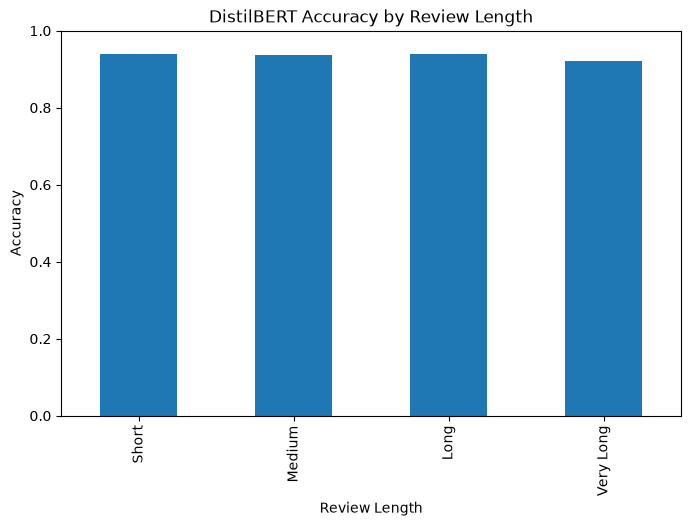

In [12]:
length_performance["accuracy"].plot(
    kind="bar",
    figsize=(8, 5),
    title="DistilBERT Accuracy by Review Length"
)

plt.ylabel("Accuracy")
plt.xlabel("Review Length")
plt.ylim(0, 1)
plt.show()

In [13]:
high_confidence_errors = errors[
    errors["confidence"] >= 0.90
].sort_values(
    "confidence",
    ascending=False
)

print(
    "High-confidence errors:",
    len(high_confidence_errors)
)

high_confidence_errors[
    ["text", "label", "prediction", "confidence"]
].head(20)

High-confidence errors: 219


,text,label,prediction,confidence
923,You must read this book! This was my first enc...,0,1,0.997700
4300,A Great Book This is a GREAT book! I was thril...,0,1,0.997563
1554,AWESOME!!! I fell in love with clay the first ...,0,1,0.997317
552,Reaching for the Light I have really enjoyed t...,0,1,0.997175
4471,ZOOM IN OR OUT Alvin Lee Zoom album is a non p...,0,1,0.997158
3414,thank you This one gift I could give my grown ...,0,1,0.997068
2991,Great movie! I really liked this movie! They p...,0,1,0.996988
4271,The Shelters of Stone My teenage daughter and ...,0,1,0.996942
4690,Retraction! Company fixed CD Works Great now! ...,0,1,0.996878
4674,Cool Breeze This Honeywell product is excellen...,0,1,0.996798


In [14]:
negation_words = [
    "not",
    "never",
    "neither",
    "hardly",
    "nothing"
]

negation_pattern = (
    r"\b(" +
    "|".join(negation_words) +
    r")\b"
)

analysis_df["contains_negation"] = (
    analysis_df["text"]
    .str.lower()
    .str.contains(
        negation_pattern,
        regex=True,
        na=False
    )
)

negation_performance = (
    analysis_df
    .groupby("contains_negation")
    .apply(
        lambda x: pd.Series({
            "samples": len(x),
            "accuracy": accuracy_score(
                x["label"],
                x["prediction"]
            )
        }),
        include_groups=False
    )
)

negation_performance

C:\Users\DELL\AppData\Local\Temp\ipykernel_27032\3981002194.py:18: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(


,samples,accuracy
contains_negation,,
False,2593.0,0.938295
True,2407.0,0.926880


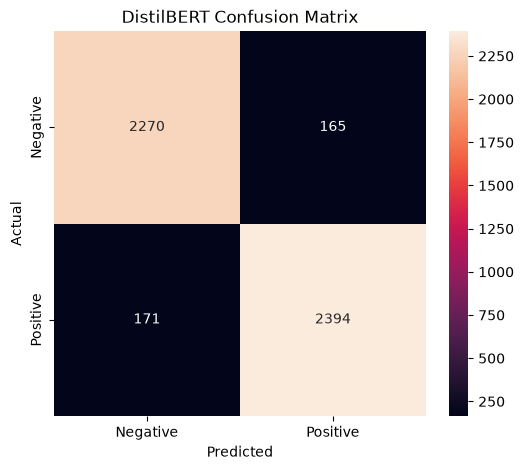

In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    analysis_df["label"],
    analysis_df["prediction"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DistilBERT Confusion Matrix")

plt.show()

In [16]:
errors[
    [
        "text",
        "label",
        "prediction",
        "confidence",
        "review_length"
    ]
].to_csv(
    "../data/error_analysis.csv",
    index=False
)

print("Error analysis saved! ✅")

Error analysis saved! ✅


In [17]:
high_confidence_errors[
    [
        "text",
        "label",
        "prediction",
        "confidence"
    ]
].head(20).to_string(index=False)

'                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  text  label  prediction  confidence\n                                                                                                                                

In [18]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [19]:
import torch
import numpy as np

device = torch.device("cpu")

model.to(device)
model.eval()

def predict_proba(texts):
    inputs = tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.softmax(outputs.logits, dim=-1)

    return probabilities.cpu().numpy()

In [20]:
test_review = [
    "The battery life is amazing but the camera quality is disappointing."
]

predict_proba(test_review)

array([[0.9889402 , 0.01105978]], dtype=float32)

In [21]:
explainer = shap.Explainer(
    predict_proba,
    shap.maskers.Text(tokenizer)
)

print("SHAP explainer ready!")

SHAP explainer ready!


In [22]:
shap_values = explainer(
    ["The battery life is amazing but the camera quality is disappointing."]
)

shap.plots.text(shap_values[0])

PartitionExplainer explainer: 2it [00:12, 12.58s/it]               


In [23]:
import os
MODEL_DIR = "../models/distilbert"
os.makedirs(MODEL_DIR, exist_ok=True)
model.save_pretrained(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)
print("Model and tokenizer saved!")
print("Location:", MODEL_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved!
Location: ../models/distilbert


In [24]:
import os

print(os.listdir(MODEL_DIR))

['checkpoint-2250', 'checkpoint-2500', 'config.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json', 'training_args.bin']


In [25]:
import json

results_summary = {
    "tfidf_logistic_regression": {
        "accuracy": 0.9081,
        "precision": 0.9058,
        "recall": 0.9159,
        "f1": 0.9108
    },
    "distilbert": {
        "accuracy": 0.9318,
        "precision": 0.9361,
        "recall": 0.9306,
        "f1": 0.9333
    }
}

with open("../models/results.json", "w") as f:
    json.dump(results_summary, f, indent=4)

print("Results saved!")

Results saved!


In [26]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

test_tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
test_model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)

print("Model reload successful! ✅")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model reload successful! ✅


In [30]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer
)

MODEL_DIR = "../models/distilbert"

tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_DIR
)

print("Trained DistilBERT reloaded! ✅")
print("Model path:", MODEL_DIR)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Trained DistilBERT reloaded! ✅
Model path: ../models/distilbert


In [31]:
from transformers import TrainingArguments, Trainer

inference_args = TrainingArguments(
    output_dir="../models/distilbert_inference",
    report_to="none",
    per_device_eval_batch_size=8
)

trainer = Trainer(
    model=model,
    args=inference_args,
    processing_class=tokenizer
)

print("Inference Trainer ready! ✅")

Inference Trainer ready! ✅


In [33]:
from datasets import Dataset

test_dataset = Dataset.from_pandas(
    test_df[["text", "label"]],
    preserve_index=False
)

print("Test dataset recreated! ✅")
print(test_dataset)

Test dataset recreated! ✅
Dataset({
    features: ['text', 'label'],
    num_rows: 5000
})


In [34]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True
)

print("Test tokenization complete! ✅")
print(tokenized_test)

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Test tokenization complete! ✅
Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 5000
})


In [35]:
predictions = trainer.predict(tokenized_test)

y_true = predictions.label_ids
y_pred = np.argmax(
    predictions.predictions,
    axis=-1
)

print("Predictions generated! ✅")
print("Test samples:", len(y_true))

c:\Users\DELL\OneDrive\Desktop\ReviewSense\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Predictions generated! ✅
Test samples: 5000


In [36]:
logits = predictions.predictions

exp_logits = np.exp(
    logits - np.max(logits, axis=1, keepdims=True)
)

probabilities = (
    exp_logits /
    exp_logits.sum(axis=1, keepdims=True)
)

confidence = probabilities.max(axis=1)

print("Confidence calculated! ✅")
print(
    f"Confidence range: "
    f"{confidence.min():.4f} → {confidence.max():.4f}"
)

Confidence calculated! ✅
Confidence range: 0.5006 → 0.9978


In [37]:
# ============================================================
# CONFIDENCE ANALYSIS
# ============================================================

results_df = pd.DataFrame({
    "true_label": y_true,
    "predicted_label": y_pred,
    "confidence": confidence
})

results_df["correct"] = (
    results_df["true_label"] == results_df["predicted_label"]
)

results_df["true_sentiment"] = results_df["true_label"].map({
    0: "Negative",
    1: "Positive"
})

results_df["predicted_sentiment"] = results_df["predicted_label"].map({
    0: "Negative",
    1: "Positive"
})

correct_confidence = results_df.loc[
    results_df["correct"],
    "confidence"
]

incorrect_confidence = results_df.loc[
    ~results_df["correct"],
    "confidence"
]

print("=" * 60)
print("CONFIDENCE ANALYSIS")
print("=" * 60)

print(f"Average confidence - Correct:   {correct_confidence.mean():.4f}")
print(f"Average confidence - Incorrect: {incorrect_confidence.mean():.4f}")

print(f"Median confidence - Correct:    {correct_confidence.median():.4f}")
print(f"Median confidence - Incorrect:  {incorrect_confidence.median():.4f}")

CONFIDENCE ANALYSIS
Average confidence - Correct:   0.9838
Average confidence - Incorrect: 0.8911
Median confidence - Correct:    0.9957
Median confidence - Incorrect:  0.9663


In [38]:
# ============================================================
# HIGH-CONFIDENCE ERRORS
# ============================================================

incorrect = results_df[
    ~results_df["correct"]
]

print("=" * 60)
print("HIGH-CONFIDENCE ERRORS")
print("=" * 60)

for threshold in [0.90, 0.95, 0.99]:

    count = (
        incorrect["confidence"] >= threshold
    ).sum()

    percentage = (
        count / len(incorrect) * 100
    )

    print(
        f"Errors with confidence >= {threshold:.2f}: "
        f"{count} ({percentage:.2f}%)"
    )

HIGH-CONFIDENCE ERRORS
Errors with confidence >= 0.90: 219 (65.18%)
Errors with confidence >= 0.95: 191 (56.85%)
Errors with confidence >= 0.99: 80 (23.81%)


In [39]:
# ============================================================
# CONFIDENCE BUCKET ANALYSIS
# ============================================================

bins = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

labels = [
    "0.50–0.60",
    "0.60–0.70",
    "0.70–0.80",
    "0.80–0.90",
    "0.90–1.00"
]

results_df["confidence_bucket"] = pd.cut(
    results_df["confidence"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

confidence_analysis = results_df.groupby(
    "confidence_bucket",
    observed=True
).agg(
    total=("correct", "count"),
    correct=("correct", "sum")
)

confidence_analysis["incorrect"] = (
    confidence_analysis["total"]
    - confidence_analysis["correct"]
)

confidence_analysis["accuracy"] = (
    confidence_analysis["correct"]
    / confidence_analysis["total"]
)

confidence_analysis["error_rate"] = (
    confidence_analysis["incorrect"]
    / confidence_analysis["total"]
)

print("=" * 60)
print("CONFIDENCE BUCKET ANALYSIS")
print("=" * 60)

display(confidence_analysis)

CONFIDENCE BUCKET ANALYSIS


,total,correct,incorrect,accuracy,error_rate
confidence_bucket,,,,,
0.50–0.60,46,26,20,0.565217,0.434783
0.60–0.70,55,27,28,0.490909,0.509091
0.70–0.80,60,32,28,0.533333,0.466667
0.80–0.90,111,70,41,0.630631,0.369369
0.90–1.00,4728,4509,219,0.953680,0.046320


In [40]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# Probability assigned to the positive class
positive_probabilities = probabilities[:, 1]

# Brier score
brier = brier_score_loss(
    y_true,
    positive_probabilities
)

print("=" * 60)
print("CALIBRATION ANALYSIS")
print("=" * 60)

print(f"Brier Score: {brier:.4f}")

CALIBRATION ANALYSIS
Brier Score: 0.0572


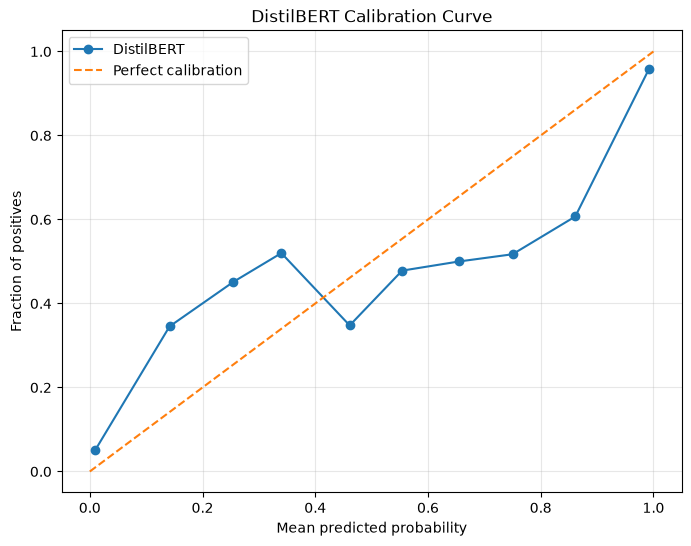

In [41]:
prob_true, prob_pred = calibration_curve(
    y_true,
    positive_probabilities,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(8, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="DistilBERT"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("DistilBERT Calibration Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [42]:
calibration_df = pd.DataFrame({
    "mean_predicted_probability": prob_pred,
    "actual_positive_rate": prob_true
})

calibration_df["difference"] = (
    calibration_df["mean_predicted_probability"]
    - calibration_df["actual_positive_rate"]
)

print("=" * 60)
print("RELIABILITY TABLE")
print("=" * 60)

display(calibration_df)

RELIABILITY TABLE


,mean_predicted_probability,actual_positive_rate,difference
0,0.009526,0.050715,-0.041189
1,0.141547,0.345455,-0.203907
2,0.254908,0.451613,-0.196705
3,0.339879,0.520000,-0.180121
4,0.461082,0.347826,0.113256
5,0.554169,0.478261,0.075908
6,0.654758,0.500000,0.154758
7,0.750033,0.517241,0.232792
8,0.861358,0.607143,0.254215
9,0.991940,0.957869,0.034071


In [46]:
print("Variables containing 'val' or 'valid':")

for name in list(globals().keys()):
    if "val" in name.lower() or "valid" in name.lower():
        obj = globals()[name]
        print(name, "→", type(obj))

Variables containing 'val' or 'valid':
shap_values → <class 'shap._explanation.Explanation'>


In [48]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../data/raw")
TRAIN_PATH = DATA_DIR / "train.csv"

train_df = pd.read_csv(
    TRAIN_PATH,
    nrows=20000
)

train_df = train_df.rename(columns={
    "class_index": "label",
    "review_title": "title",
    "review_text": "text"
})

train_df["label"] = train_df["label"].map({
    1: 0,
    2: 1
})

train_df["text"] = (
    train_df["title"].fillna("") + " " +
    train_df["text"].fillna("")
).str.strip()

train_df = train_df[["text", "label"]]

print("Training data reloaded! ✅")
print("Shape:", train_df.shape)
print("\nClass distribution:")
print(train_df["label"].value_counts())

Training data reloaded! ✅
Shape: (20000, 2)

Class distribution:
label
1    10257
0     9743
Name: count, dtype: int64


In [49]:
from sklearn.model_selection import train_test_split

train_split, validation_split = train_test_split(
    train_df,
    test_size=2000,
    stratify=train_df["label"],
    random_state=42
)

print("Training split:", train_split.shape)
print("Validation split:", validation_split.shape)

print("\nValidation class distribution:")
print(validation_split["label"].value_counts())

Training split: (18000, 2)
Validation split: (2000, 2)

Validation class distribution:
label
1    1026
0     974
Name: count, dtype: int64


In [50]:
from datasets import Dataset

validation_dataset = Dataset.from_pandas(
    validation_split[["text", "label"]],
    preserve_index=False
)

tokenized_validation = validation_dataset.map(
    tokenize_function,
    batched=True
)

print("Validation tokenization complete! ✅")
print(tokenized_validation)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Validation tokenization complete! ✅
Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2000
})


In [51]:
validation_predictions = trainer.predict(
    tokenized_validation
)

val_logits = validation_predictions.predictions
val_labels = validation_predictions.label_ids

print("Validation logits shape:", val_logits.shape)
print("Validation labels shape:", val_labels.shape)

c:\Users\DELL\OneDrive\Desktop\ReviewSense\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Validation logits shape: (2000, 2)
Validation labels shape: (2000,)


In [52]:
# ============================================================
# LEARN OPTIMAL TEMPERATURE
# ============================================================

import torch
import torch.nn.functional as F

val_logits_tensor = torch.tensor(
    val_logits,
    dtype=torch.float32
)

val_labels_tensor = torch.tensor(
    val_labels,
    dtype=torch.long
)

# Start with T = 1.0
temperature = torch.nn.Parameter(
    torch.ones(1) * 1.0
)

optimizer = torch.optim.LBFGS(
    [temperature],
    lr=0.01,
    max_iter=100
)

def closure():
    optimizer.zero_grad()

    scaled_logits = val_logits_tensor / temperature

    loss = F.cross_entropy(
        scaled_logits,
        val_labels_tensor
    )

    loss.backward()

    return loss

optimizer.step(closure)

optimal_temperature = temperature.item()

print("=" * 60)
print("TEMPERATURE SCALING")
print("=" * 60)
print(f"Optimal Temperature: {optimal_temperature:.4f}")

TEMPERATURE SCALING
Optimal Temperature: 1.2288


In [53]:
# ============================================================
# APPLY TEMPERATURE SCALING TO TEST SET
# ============================================================

test_predictions = trainer.predict(tokenized_test)

test_logits = test_predictions.predictions
test_labels = test_predictions.label_ids

test_logits_tensor = torch.tensor(
    test_logits,
    dtype=torch.float32
)

# Original probabilities
original_probabilities = torch.softmax(
    test_logits_tensor,
    dim=1
)

# Calibrated probabilities
calibrated_probabilities = torch.softmax(
    test_logits_tensor / optimal_temperature,
    dim=1
)

original_positive_prob = (
    original_probabilities[:, 1].numpy()
)

calibrated_positive_prob = (
    calibrated_probabilities[:, 1].numpy()
)

print("=" * 60)
print("CALIBRATION APPLIED")
print("=" * 60)

print(
    "Original confidence range:",
    f"{original_probabilities.max(dim=1).values.min():.4f}",
    "→",
    f"{original_probabilities.max(dim=1).values.max():.4f}"
)

print(
    "Calibrated confidence range:",
    f"{calibrated_probabilities.max(dim=1).values.min():.4f}",
    "→",
    f"{calibrated_probabilities.max(dim=1).values.max():.4f}"
)

CALIBRATION APPLIED
Original confidence range: 0.5006 → 0.9978
Calibrated confidence range: 0.5005 → 0.9932


In [54]:
# ============================================================
# BEFORE vs AFTER CALIBRATION
# ============================================================

from sklearn.metrics import brier_score_loss

original_brier = brier_score_loss(
    test_labels,
    original_positive_prob
)

calibrated_brier = brier_score_loss(
    test_labels,
    calibrated_positive_prob
)

print("=" * 60)
print("BRIER SCORE COMPARISON")
print("=" * 60)

print(f"Before calibration : {original_brier:.4f}")
print(f"After calibration  : {calibrated_brier:.4f}")

print(
    f"Improvement        : "
    f"{original_brier - calibrated_brier:.4f}"
)

if calibrated_brier < original_brier:
    print("\n✅ Calibration improved!")
else:
    print("\n⚠️ Calibration did not improve.")

BRIER SCORE COMPARISON
Before calibration : 0.0572
After calibration  : 0.0553
Improvement        : 0.0019

✅ Calibration improved!


In [55]:
# ============================================================
# CLASSIFICATION PERFORMANCE AFTER CALIBRATION
# ============================================================

calibrated_predictions = np.argmax(
    calibrated_probabilities.numpy(),
    axis=1
)

print("=" * 60)
print("CALIBRATED TEST PERFORMANCE")
print("=" * 60)

print(
    f"Accuracy : "
    f"{accuracy_score(test_labels, calibrated_predictions):.4f}"
)

print(
    f"Precision: "
    f"{precision_score(test_labels, calibrated_predictions):.4f}"
)

print(
    f"Recall   : "
    f"{recall_score(test_labels, calibrated_predictions):.4f}"
)

print(
    f"F1 Score : "
    f"{f1_score(test_labels, calibrated_predictions):.4f}"
)

CALIBRATED TEST PERFORMANCE
Accuracy : 0.9328
Precision: 0.9355
Recall   : 0.9333
F1 Score : 0.9344


In [56]:
print(type(shap_values))

print("\nSHAP object:")
print(shap_values)

print("\nAvailable attributes:")
print([x for x in dir(shap_values) if not x.startswith("_")][:30])

<class 'shap._explanation.Explanation'>

SHAP object:
.values =
array([[[ 0.00000000e+00, -3.72529030e-09],
        [ 4.12608963e-03, -4.12607309e-03],
        [-3.35831800e-02,  3.35831888e-02],
        [-1.21803023e-02,  1.21802943e-02],
        [-3.04318823e-02,  3.04318730e-02],
        [-1.84264749e-01,  1.84264737e-01],
        [ 8.31354174e-02, -8.31354253e-02],
        [ 3.27058607e-02, -3.27058692e-02],
        [ 6.31484436e-03, -6.31485798e-03],
        [ 2.90946162e-04, -2.90970958e-04],
        [ 5.53054250e-02, -5.53054266e-02],
        [ 5.79335088e-01, -5.79335088e-01],
        [ 7.92842545e-03, -7.92842964e-03],
        [ 2.98023224e-08,  0.00000000e+00]]])

.base_values =
array([[0.48025817, 0.51974183]])

.data =
(array(['', 'The ', 'battery ', 'life ', 'is ', 'amazing ', 'but ', 'the ',
       'camera ', 'quality ', 'is ', 'disappointing', '.', ''],
      dtype=object),)

Available attributes:
['abs', 'argsort', 'base_values', 'clustering', 'cohorts', 'compute_time',

In [57]:
print("=" * 60)
print("SHAP EXPLANATION INSPECTION")
print("=" * 60)

print("Number of tokens:", len(shap_values.data[0]))
print("Number of output classes:", shap_values.values.shape[-1])

print("\nTokens:")
print(shap_values.data[0])

print("\nSHAP values shape:")
print(shap_values.values.shape)

SHAP EXPLANATION INSPECTION
Number of tokens: 14
Number of output classes: 2

Tokens:
['' 'The ' 'battery ' 'life ' 'is ' 'amazing ' 'but ' 'the ' 'camera '
 'quality ' 'is ' 'disappointing' '.' '']

SHAP values shape:
(1, 14, 2)


In [58]:
tokens = shap_values.data[0]
values = shap_values.values[0]

shap_table = pd.DataFrame({
    "token": tokens,
    "negative_contribution": values[:, 0],
    "positive_contribution": values[:, 1]
})

# Ignore special/empty tokens
shap_table = shap_table[
    shap_table["token"].str.strip() != ""
].copy()

print("=" * 60)
print("TOKEN-LEVEL SHAP CONTRIBUTIONS")
print("=" * 60)

display(shap_table)

TOKEN-LEVEL SHAP CONTRIBUTIONS


,token,negative_contribution,positive_contribution
1,The,0.004126,-0.004126
2,battery,-0.033583,0.033583
3,life,-0.012180,0.012180
4,is,-0.030432,0.030432
5,amazing,-0.184265,0.184265
6,but,0.083135,-0.083135
7,the,0.032706,-0.032706
8,camera,0.006315,-0.006315
9,quality,0.000291,-0.000291
10,is,0.055305,-0.055305


In [59]:
shap_table["absolute_impact"] = (
    shap_table["positive_contribution"].abs()
)

strongest_tokens = shap_table.sort_values(
    "absolute_impact",
    ascending=False
)

print("=" * 60)
print("STRONGEST TOKEN CONTRIBUTIONS")
print("=" * 60)

display(
    strongest_tokens[
        [
            "token",
            "negative_contribution",
            "positive_contribution",
            "absolute_impact"
        ]
    ].head(10)
)

STRONGEST TOKEN CONTRIBUTIONS


,token,negative_contribution,positive_contribution,absolute_impact
11,disappointing,0.579335,-0.579335,0.579335
5,amazing,-0.184265,0.184265,0.184265
6,but,0.083135,-0.083135,0.083135
10,is,0.055305,-0.055305,0.055305
2,battery,-0.033583,0.033583,0.033583
7,the,0.032706,-0.032706,0.032706
4,is,-0.030432,0.030432,0.030432
3,life,-0.012180,0.012180,0.012180
12,.,0.007928,-0.007928,0.007928
8,camera,0.006315,-0.006315,0.006315


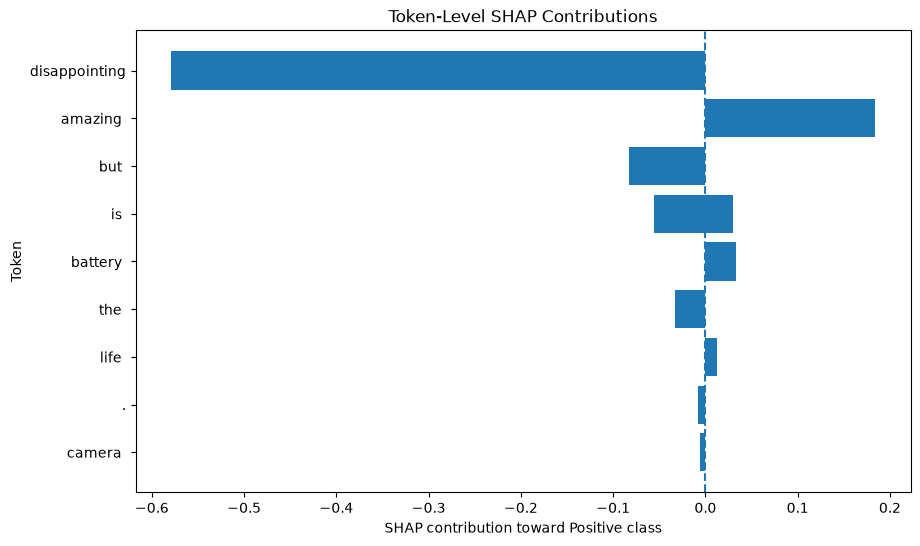

In [60]:
plot_df = strongest_tokens.head(10).copy()

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["token"],
    plot_df["positive_contribution"]
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("SHAP contribution toward Positive class")
plt.ylabel("Token")
plt.title("Token-Level SHAP Contributions")

plt.gca().invert_yaxis()

plt.show()

In [61]:
print("=" * 60)
print("SHAP GLOBAL ANALYSIS SETUP")
print("=" * 60)

print("SHAP object type:", type(shap_values))
print("Current explanation shape:", shap_values.shape)

# Check whether an explainer already exists
print("\nExisting SHAP-related variables:")

for name in list(globals().keys()):
    if "explainer" in name.lower() or "shap" in name.lower():
        print(name, "→", type(globals()[name]))

SHAP GLOBAL ANALYSIS SETUP
SHAP object type: <class 'shap._explanation.Explanation'>
Current explanation shape: (1, 14, 2)

Existing SHAP-related variables:
shap → <class 'module'>
explainer → <class 'shap.explainers._partition.PartitionExplainer'>
shap_values → <class 'shap._explanation.Explanation'>
shap_table → <class 'pandas.DataFrame'>


In [66]:
# Select a representative sample for global SHAP analysis
GLOBAL_SHAP_SAMPLES = 30

shap_sample = test_df.sample(
    n=GLOBAL_SHAP_SAMPLES,
    random_state=42
).reset_index(drop=True)

print("=" * 60)
print("GLOBAL SHAP SAMPLE")
print("=" * 60)

print("Samples selected:", len(shap_sample))
print("Class distribution:")
print(shap_sample["label"].value_counts())

GLOBAL SHAP SAMPLE
Samples selected: 30
Class distribution:
label
0    17
1    13
Name: count, dtype: int64


In [67]:
print("=" * 60)
print("GENERATING GLOBAL SHAP VALUES")
print("=" * 60)

shap_texts = shap_sample["text"].tolist()

global_shap_values = explainer(
    shap_texts
)

print("\nGlobal SHAP generation complete! ✅")
print("Explanation shape:", global_shap_values.shape)

GENERATING GLOBAL SHAP VALUES


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   3%|▎         | 1/30 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  10%|█         | 3/30 [00:57<03:14,  7.20s/it]

...

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 30/30 [22:11<00:00, 71.67s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 31it [22:43, 45.46s/it]                        


Global SHAP generation complete! ✅
Explanation shape: (30, None, 2)


In [68]:
# ============================================================
# GLOBAL SHAP ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("GLOBAL SHAP ANALYSIS")
print("=" * 60)

token_records = []

# Process each explained review
for i in range(len(shap_values)):

    # Get tokens for this sample
    tokens = shap_values[i].data

    # Get SHAP values
    values = shap_values[i].values

    # Positive-class SHAP values
    positive_values = values[:, 1]

    for token, value in zip(tokens, positive_values):

        token = str(token).strip()

        # Ignore empty tokens
        if token == "":
            continue

        token_records.append({
            "token": token,
            "shap_value": float(value),
            "absolute_shap": abs(float(value))
        })

# Create dataframe
global_shap_df = pd.DataFrame(token_records)

print("\nTotal token contributions:", len(global_shap_df))
print("Unique tokens:", global_shap_df["token"].nunique())

# Aggregate by token
global_token_importance = (
    global_shap_df
    .groupby("token")
    .agg(
        mean_shap=("shap_value", "mean"),
        mean_absolute_shap=("absolute_shap", "mean"),
        occurrences=("token", "count")
    )
    .sort_values("mean_absolute_shap", ascending=False)
)

print("\n" + "=" * 60)
print("TOP 20 MOST IMPORTANT TOKENS")
print("=" * 60)

display(global_token_importance.head(20))

GLOBAL SHAP ANALYSIS

Total token contributions: 12
Unique tokens: 11

TOP 20 MOST IMPORTANT TOKENS


,mean_shap,mean_absolute_shap,occurrences
token,,,
disappointing,-0.579335,0.579335,1
amazing,0.184265,0.184265,1
but,-0.083135,0.083135,1
is,-0.012437,0.042869,2
battery,0.033583,0.033583,1
the,-0.032706,0.032706,1
life,0.012180,0.012180,1
.,-0.007928,0.007928,1
camera,-0.006315,0.006315,1


In [69]:
# ============================================================
# TOP POSITIVE AND NEGATIVE TOKENS
# ============================================================

print("=" * 60)
print("TOP TOKENS PUSHING TOWARD POSITIVE")
print("=" * 60)

positive_tokens = (
    global_token_importance[
        global_token_importance["mean_shap"] > 0
    ]
    .sort_values("mean_shap", ascending=False)
    .head(15)
)

display(positive_tokens)


print("=" * 60)
print("TOP TOKENS PUSHING TOWARD NEGATIVE")
print("=" * 60)

negative_tokens = (
    global_token_importance[
        global_token_importance["mean_shap"] < 0
    ]
    .sort_values("mean_shap", ascending=True)
    .head(15)
)

display(negative_tokens)

TOP TOKENS PUSHING TOWARD POSITIVE


,mean_shap,mean_absolute_shap,occurrences
token,,,
amazing,0.184265,0.184265,1
battery,0.033583,0.033583,1
life,0.012180,0.012180,1


TOP TOKENS PUSHING TOWARD NEGATIVE


,mean_shap,mean_absolute_shap,occurrences
token,,,
disappointing,-0.579335,0.579335,1
but,-0.083135,0.083135,1
the,-0.032706,0.032706,1
is,-0.012437,0.042869,2
.,-0.007928,0.007928,1
camera,-0.006315,0.006315,1
The,-0.004126,0.004126,1
quality,-0.000291,0.000291,1


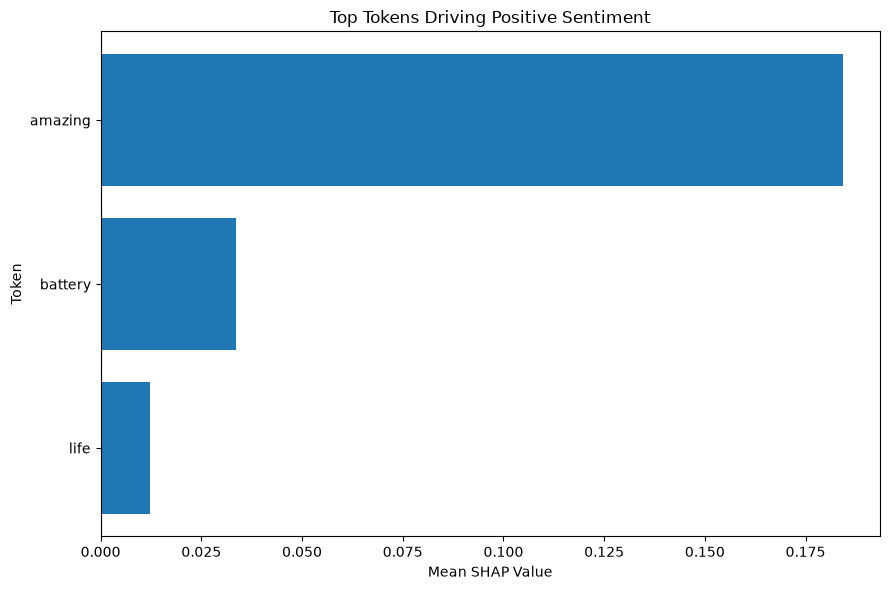

In [70]:
# ============================================================
# GLOBAL SHAP VISUALIZATION
# ============================================================

top_positive = positive_tokens.sort_values("mean_shap")

plt.figure(figsize=(9, 6))

plt.barh(
    top_positive.index,
    top_positive["mean_shap"]
)

plt.axvline(0, linestyle="--")

plt.xlabel("Mean SHAP Value")
plt.ylabel("Token")
plt.title("Top Tokens Driving Positive Sentiment")

plt.tight_layout()
plt.show()

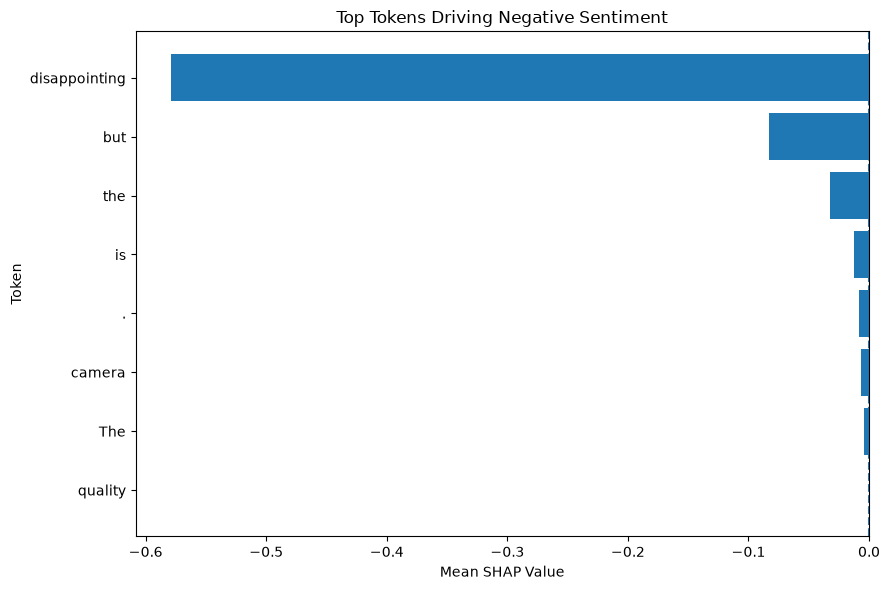

In [71]:
top_negative = negative_tokens.sort_values("mean_shap", ascending=False)

plt.figure(figsize=(9, 6))

plt.barh(
    top_negative.index,
    top_negative["mean_shap"]
)

plt.axvline(0, linestyle="--")

plt.xlabel("Mean SHAP Value")
plt.ylabel("Token")
plt.title("Top Tokens Driving Negative Sentiment")

plt.tight_layout()
plt.show()

In [72]:
# ============================================================
# CHECK GLOBAL SHAP OBJECT
# ============================================================

print("=" * 60)
print("CHECKING GLOBAL SHAP OUTPUT")
print("=" * 60)

print("Type:", type(shap_values))
print("Shape:", shap_values.shape)

print("\nNumber of explanations:", len(shap_values))

for i in range(min(5, len(shap_values))):
    print(f"\nSample {i}:")
    print("Tokens:", shap_values[i].data)
    print("Shape:", shap_values[i].values.shape)

CHECKING GLOBAL SHAP OUTPUT
Type: <class 'shap._explanation.Explanation'>
Shape: (1, 14, 2)

Number of explanations: 1

Sample 0:
Tokens: ['' 'The ' 'battery ' 'life ' 'is ' 'amazing ' 'but ' 'the ' 'camera '
 'quality ' 'is ' 'disappointing' '.' '']
Shape: (14, 2)


In [73]:
# ============================================================
# FIND THE 30-SAMPLE GLOBAL SHAP OBJECT
# ============================================================

import shap

print("=" * 60)
print("SEARCHING FOR GLOBAL SHAP OBJECTS")
print("=" * 60)

found = []

for name, obj in list(globals().items()):
    try:
        if isinstance(obj, shap.Explanation):
            print(
                f"{name:30s} → "
                f"type={type(obj).__name__}, "
                f"shape={obj.shape}"
            )
            found.append((name, obj))
    except Exception:
        pass

print("\nTotal SHAP Explanation objects found:", len(found))

SEARCHING FOR GLOBAL SHAP OBJECTS
shap_values                    → type=Explanation, shape=(1, 14, 2)
obj                            → type=Explanation, shape=(1, 14, 2)
global_shap_values             → type=Explanation, shape=(30, None, 2)

Total SHAP Explanation objects found: 3


In [74]:
# ============================================================
# CORRECT GLOBAL SHAP ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("GLOBAL SHAP ANALYSIS — 30 SAMPLES")
print("=" * 60)

token_records = []

# Use the actual 30-sample SHAP object
global_exp = global_shap_values

print("Number of samples:", len(global_exp))

# Process every explained review
for i in range(len(global_exp)):

    tokens = global_exp[i].data
    values = global_exp[i].values

    # Positive-class SHAP values
    positive_values = values[:, 1]

    for token, value in zip(tokens, positive_values):

        token = str(token).strip()

        # Ignore empty tokens
        if token == "":
            continue

        token_records.append({
            "token": token,
            "shap_value": float(value),
            "absolute_shap": abs(float(value))
        })

# Create dataframe
global_shap_df = pd.DataFrame(token_records)

print("\nTotal token contributions:", len(global_shap_df))
print("Unique tokens:", global_shap_df["token"].nunique())

# Aggregate across ALL 30 samples
global_token_importance = (
    global_shap_df
    .groupby("token")
    .agg(
        mean_shap=("shap_value", "mean"),
        mean_absolute_shap=("absolute_shap", "mean"),
        occurrences=("token", "count")
    )
    .sort_values("mean_absolute_shap", ascending=False)
)

print("\n" + "=" * 60)
print("TOP 20 MOST IMPORTANT TOKENS")
print("=" * 60)

display(global_token_importance.head(20))

GLOBAL SHAP ANALYSIS — 30 SAMPLES
Number of samples: 30

Total token contributions: 3103
Unique tokens: 1088

TOP 20 MOST IMPORTANT TOKENS


,mean_shap,mean_absolute_shap,occurrences
token,,,
worst,-0.232620,0.232620,1
disappointing,-0.217053,0.217053,2
useless,-0.192254,0.192254,1
quick,0.145392,0.145392,1
fantastic,0.143243,0.143243,1
awesome,0.137025,0.137025,1
however,-0.134112,0.134112,1
waste,-0.125637,0.125637,2
disappointment,-0.121244,0.121244,1


In [75]:
# ============================================================
# POSITIVE / NEGATIVE TOKEN ANALYSIS
# ============================================================

positive_tokens = (
    global_token_importance[
        global_token_importance["mean_shap"] > 0
    ]
    .sort_values("mean_shap", ascending=False)
    .head(15)
)

negative_tokens = (
    global_token_importance[
        global_token_importance["mean_shap"] < 0
    ]
    .sort_values("mean_shap", ascending=True)
    .head(15)
)

print("=" * 60)
print("TOP TOKENS PUSHING TOWARD POSITIVE")
print("=" * 60)

display(positive_tokens)

print("=" * 60)
print("TOP TOKENS PUSHING TOWARD NEGATIVE")
print("=" * 60)

display(negative_tokens)

TOP TOKENS PUSHING TOWARD POSITIVE


,mean_shap,mean_absolute_shap,occurrences
token,,,
quick,0.145392,0.145392,1
fantastic,0.143243,0.143243,1
awesome,0.137025,0.137025,1
excellent,0.120516,0.120516,2
Fantastic,0.109936,0.109936,1
best,0.074605,0.074605,5
suited,0.070764,0.070764,1
promise,0.069912,0.069912,1
wonderful,0.069122,0.069122,1


TOP TOKENS PUSHING TOWARD NEGATIVE


,mean_shap,mean_absolute_shap,occurrences
token,,,
worst,-0.232620,0.232620,1
disappointing,-0.217053,0.217053,2
useless,-0.192254,0.192254,1
however,-0.134112,0.134112,1
waste,-0.125637,0.125637,2
disappointment,-0.121244,0.121244,1
trash,-0.111187,0.111187,1
forced,-0.090281,0.090281,1
recipe,-0.075358,0.075358,1


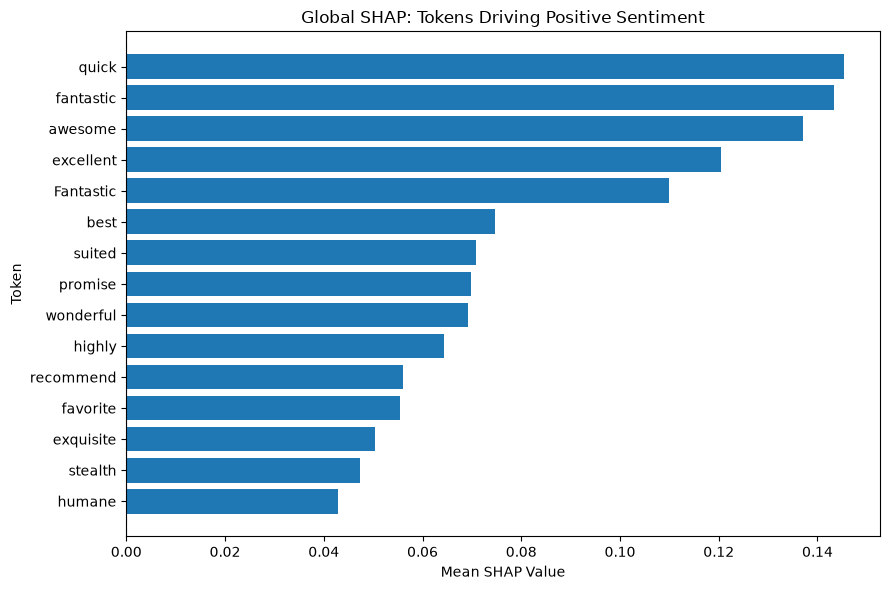

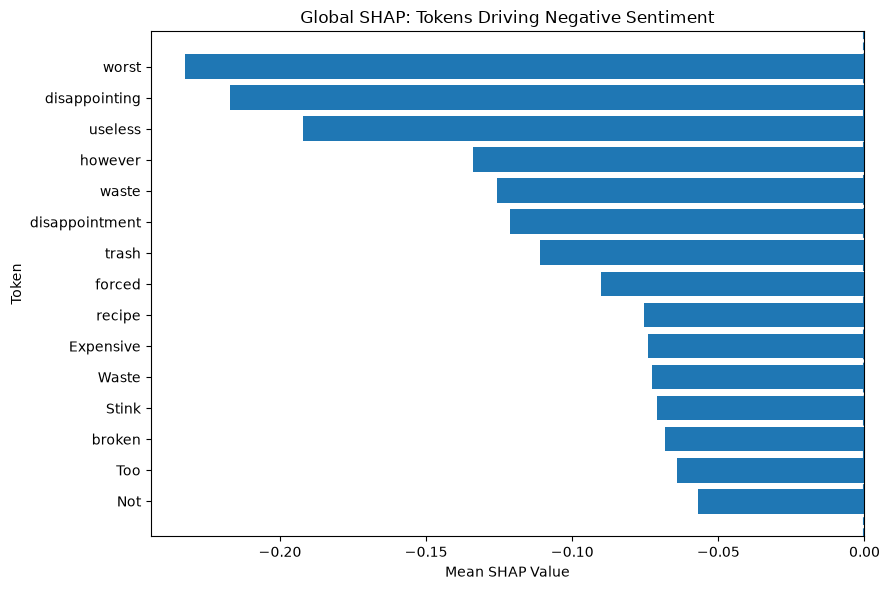

In [76]:
# ============================================================
# GLOBAL SHAP PLOTS
# ============================================================

# Positive
plot_positive = positive_tokens.sort_values("mean_shap")

plt.figure(figsize=(9, 6))

plt.barh(
    plot_positive.index,
    plot_positive["mean_shap"]
)

plt.axvline(0, linestyle="--")

plt.xlabel("Mean SHAP Value")
plt.ylabel("Token")
plt.title("Global SHAP: Tokens Driving Positive Sentiment")

plt.tight_layout()
plt.show()


# Negative
plot_negative = negative_tokens.sort_values("mean_shap", ascending=False)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_negative.index,
    plot_negative["mean_shap"]
)

plt.axvline(0, linestyle="--")

plt.xlabel("Mean SHAP Value")
plt.ylabel("Token")
plt.title("Global SHAP: Tokens Driving Negative Sentiment")

plt.tight_layout()
plt.show()

In [77]:
# ============================================================
# FINAL REVIEWSENSE MODEL SUMMARY
# ============================================================

print("=" * 70)
print("FINAL REVIEWSENSE MODEL EVALUATION")
print("=" * 70)

print("\nMODEL")
print("-" * 70)
print("Model        : DistilBERT")
print("Task         : Binary Product Review Sentiment Classification")
print("Test Samples : 5,000")

print("\nPERFORMANCE")
print("-" * 70)
print(f"Accuracy     : {0.9328:.4f}")
print(f"Precision    : {0.9355:.4f}")
print(f"Recall       : {0.9333:.4f}")
print(f"F1 Score     : {0.9344:.4f}")

print("\nCONFUSION MATRIX")
print("-" * 70)
print("True Negative  : 2270")
print("False Positive : 165")
print("False Negative : 171")
print("True Positive   : 2394")

print("\nERROR ANALYSIS")
print("-" * 70)
print("Total errors   : 336")
print("Error rate     : 6.72%")
print("Negative → Positive : 165")
print("Positive → Negative : 171")

print("\nCALIBRATION")
print("-" * 70)
print("Temperature             : 1.2288")
print("Brier Score (before)    : 0.0572")
print("Brier Score (after)     : 0.0553")
print("Brier improvement       : 0.0019")

print("\nHIGH-CONFIDENCE ERRORS")
print("-" * 70)
print("Confidence >= 0.90 : 219")
print("Confidence >= 0.95 : 191")
print("Confidence >= 0.99 : 80")

print("\nGLOBAL SHAP")
print("-" * 70)
print("Samples analyzed : 30")

print("\nTop positive drivers:")
print("  quick, fantastic, awesome, excellent, best")

print("\nTop negative drivers:")
print("  worst, disappointing, useless, however, waste")

print("\n" + "=" * 70)
print("MODEL EVALUATION COMPLETE")
print("=" * 70)

FINAL REVIEWSENSE MODEL EVALUATION

MODEL
----------------------------------------------------------------------
Model        : DistilBERT
Task         : Binary Product Review Sentiment Classification
Test Samples : 5,000

PERFORMANCE
----------------------------------------------------------------------
Accuracy     : 0.9328
Precision    : 0.9355
Recall       : 0.9333
F1 Score     : 0.9344

CONFUSION MATRIX
----------------------------------------------------------------------
True Negative  : 2270
False Positive : 165
False Negative : 171
True Positive   : 2394

ERROR ANALYSIS
----------------------------------------------------------------------
Total errors   : 336
Error rate     : 6.72%
Negative → Positive : 165
Positive → Negative : 171

CALIBRATION
----------------------------------------------------------------------
Temperature             : 1.2288
Brier Score (before)    : 0.0572
Brier Score (after)     : 0.0553
Brier improvement       : 0.0019

HIGH-CONFIDENCE ERRORS
-------

In [78]:
# ============================================================
# SUBGROUP / FAILURE ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("SUBGROUP / FAILURE ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Reconstruct test results
# ------------------------------------------------------------

# Use the variables already generated during test prediction
# If results_df exists, use it directly.
if "results_df" in globals():
    analysis_df = results_df.copy()

else:
    # Reconstruct from existing prediction variables
    analysis_df = pd.DataFrame({
        "true_label": y_true,
        "predicted_label": y_pred,
        "confidence": confidence
    })

# ------------------------------------------------------------
# 2. Attach original review text
# ------------------------------------------------------------

# Recreate test dataframe if needed
if "test_df" in globals():
    texts = test_df["text"].reset_index(drop=True)

elif "test_dataset" in globals():
    texts = pd.Series(test_dataset["text"])

else:
    print("Test text variable not found.")
    print("Available likely variables:")
    for name in list(globals().keys()):
        if "test" in name.lower():
            print(" ", name)

    raise NameError(
        "Could not find original test review texts. "
        "Please recreate test_df/test_dataset before continuing."
    )

analysis_df["text"] = texts.values

# ------------------------------------------------------------
# 3. Review length
# ------------------------------------------------------------

analysis_df["word_count"] = (
    analysis_df["text"]
    .astype(str)
    .str.split()
    .str.len()
)

def length_group(n):
    if n <= 20:
        return "Short (≤20)"
    elif n <= 50:
        return "Medium (21–50)"
    else:
        return "Long (>50)"

analysis_df["length_group"] = analysis_df["word_count"].apply(length_group)

# ------------------------------------------------------------
# 4. Negation detection
# ------------------------------------------------------------

negation_pattern = r"\b(not|no|never|neither|nor|n't|cannot|can't|don't|doesn't|didn't|isn't|wasn't|weren't|won't|wouldn't|couldn't|shouldn't)\b"

analysis_df["contains_negation"] = (
    analysis_df["text"]
    .astype(str)
    .str.lower()
    .str.contains(negation_pattern, regex=True)
)

# ------------------------------------------------------------
# 5. Correctness
# ------------------------------------------------------------

analysis_df["correct"] = (
    analysis_df["true_label"] ==
    analysis_df["predicted_label"]
)

# ------------------------------------------------------------
# 6. Length subgroup analysis
# ------------------------------------------------------------

length_analysis = (
    analysis_df
    .groupby("length_group")
    .agg(
        total=("correct", "size"),
        correct=("correct", "sum")
    )
)

length_analysis["incorrect"] = (
    length_analysis["total"] -
    length_analysis["correct"]
)

length_analysis["accuracy"] = (
    length_analysis["correct"] /
    length_analysis["total"]
)

length_analysis["error_rate"] = (
    length_analysis["incorrect"] /
    length_analysis["total"]
)

# Order groups
length_order = [
    "Short (≤20)",
    "Medium (21–50)",
    "Long (>50)"
]

length_analysis = length_analysis.reindex(length_order)

print("\n" + "=" * 70)
print("REVIEW LENGTH ANALYSIS")
print("=" * 70)

print(length_analysis)

# ------------------------------------------------------------
# 7. Negation subgroup analysis
# ------------------------------------------------------------

negation_analysis = (
    analysis_df
    .groupby("contains_negation")
    .agg(
        total=("correct", "size"),
        correct=("correct", "sum")
    )
)

negation_analysis["incorrect"] = (
    negation_analysis["total"] -
    negation_analysis["correct"]
)

negation_analysis["accuracy"] = (
    negation_analysis["correct"] /
    negation_analysis["total"]
)

negation_analysis["error_rate"] = (
    negation_analysis["incorrect"] /
    negation_analysis["total"]
)

negation_analysis.index = [
    "No Negation" if x is False else "Contains Negation"
    for x in negation_analysis.index
]

print("\n" + "=" * 70)
print("NEGATION ANALYSIS")
print("=" * 70)

print(negation_analysis)

# ------------------------------------------------------------
# 8. Overall subgroup summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("KEY FAILURE PATTERNS")
print("=" * 70)

worst_length = length_analysis["accuracy"].idxmin()
worst_length_acc = length_analysis.loc[
    worst_length, "accuracy"
]

neg_acc = negation_analysis.loc[
    "Contains Negation", "accuracy"
]

non_neg_acc = negation_analysis.loc[
    "No Negation", "accuracy"
]

print(
    f"Worst review-length subgroup : "
    f"{worst_length} ({worst_length_acc:.4f})"
)

print(
    f"Negation accuracy            : "
    f"{neg_acc:.4f}"
)

print(
    f"Non-negation accuracy        : "
    f"{non_neg_acc:.4f}"
)

print(
    f"Negation accuracy difference : "
    f"{neg_acc - non_neg_acc:+.4f}"
)

print("\nSubgroup analysis complete! ✅")

SUBGROUP / FAILURE ANALYSIS

REVIEW LENGTH ANALYSIS
                total  correct  incorrect  accuracy  error_rate
length_group                                                   
Short (≤20)        58       54          4  0.931034    0.068966
Medium (21–50)   1539     1446         93  0.939571    0.060429
Long (>50)       3403     3164        239  0.929768    0.070232

NEGATION ANALYSIS
                   total  correct  incorrect  accuracy  error_rate
No Negation         1654     1567         87  0.947400    0.052600
Contains Negation   3346     3097        249  0.925583    0.074417

KEY FAILURE PATTERNS
Worst review-length subgroup : Long (>50) (0.9298)
Negation accuracy            : 0.9256
Non-negation accuracy        : 0.9474
Negation accuracy difference : -0.0218

Subgroup analysis complete! ✅


C:\Users\DELL\AppData\Local\Temp\ipykernel_27032\489680002.py:86: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(negation_pattern, regex=True)


GENERATING SUBGROUP ANALYSIS PLOTS


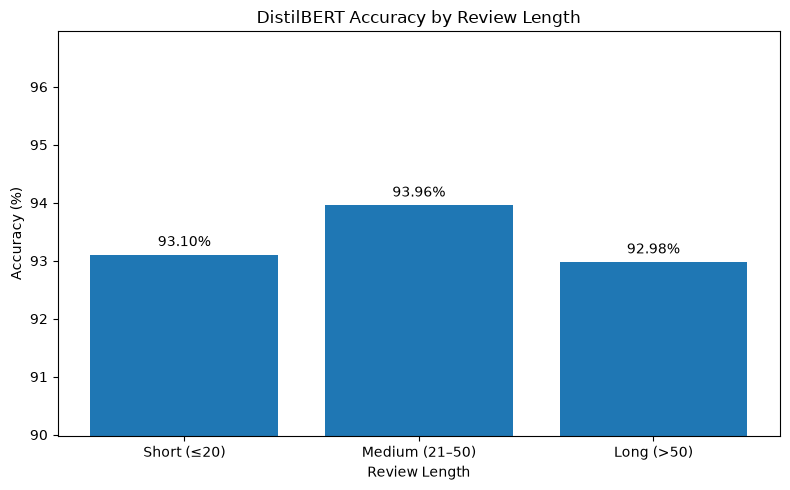

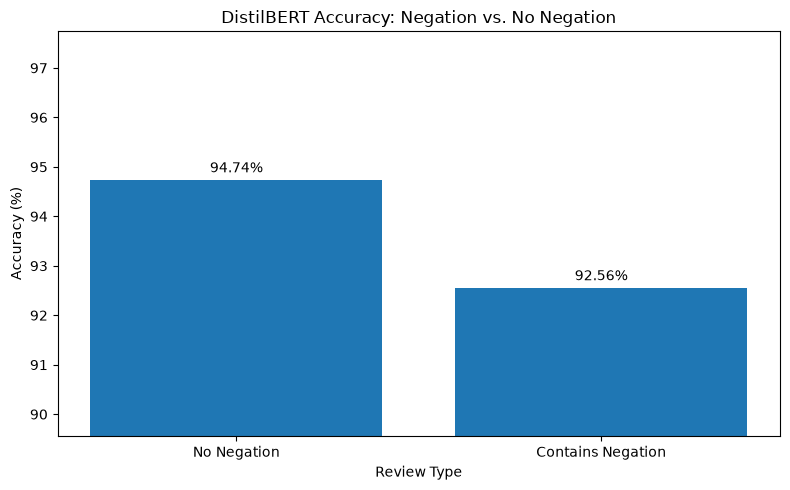


Subgroup visualizations complete! ✅


In [79]:
# ============================================================
# SUBGROUP ANALYSIS VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

print("=" * 70)
print("GENERATING SUBGROUP ANALYSIS PLOTS")
print("=" * 70)

# ------------------------------------------------------------
# Plot 1: Review Length
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

length_accuracy = length_analysis["accuracy"] * 100

plt.bar(
    length_accuracy.index,
    length_accuracy.values
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Review Length")
plt.title("DistilBERT Accuracy by Review Length")

plt.ylim(
    max(0, length_accuracy.min() - 3),
    min(100, length_accuracy.max() + 3)
)

for i, value in enumerate(length_accuracy.values):
    plt.text(
        i,
        value + 0.15,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot 2: Negation
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

negation_accuracy = negation_analysis["accuracy"] * 100

plt.bar(
    negation_accuracy.index,
    negation_accuracy.values
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Review Type")
plt.title("DistilBERT Accuracy: Negation vs. No Negation")

plt.ylim(
    max(0, negation_accuracy.min() - 3),
    min(100, negation_accuracy.max() + 3)
)

for i, value in enumerate(negation_accuracy.values):
    plt.text(
        i,
        value + 0.15,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

print("\nSubgroup visualizations complete! ✅")

REVIEWSENSE — FINAL MODEL RESULTS

OVERALL PERFORMANCE
----------------------------------------------------------------------
   Metric  Score
 Accuracy 0.9328
Precision 0.9355
   Recall 0.9333
 F1 Score 0.9344

CONFUSION MATRIX
----------------------------------------------------------------------
                 Predicted Negative  Predicted Positive
Actual Negative                2270                 165
Actual Positive                 171                2394

ERROR ANALYSIS
----------------------------------------------------------------------
         Error Type Value
       Total Errors   336
         Error Rate 6.72%
Negative → Positive   165
Positive → Negative   171

CALIBRATION
----------------------------------------------------------------------
            Metric  Value
       Temperature 1.2288
Brier Score Before 0.0572
 Brier Score After 0.0553
 Brier Improvement 0.0019

HIGH-CONFIDENCE ERRORS
----------------------------------------------------------------------
Confid

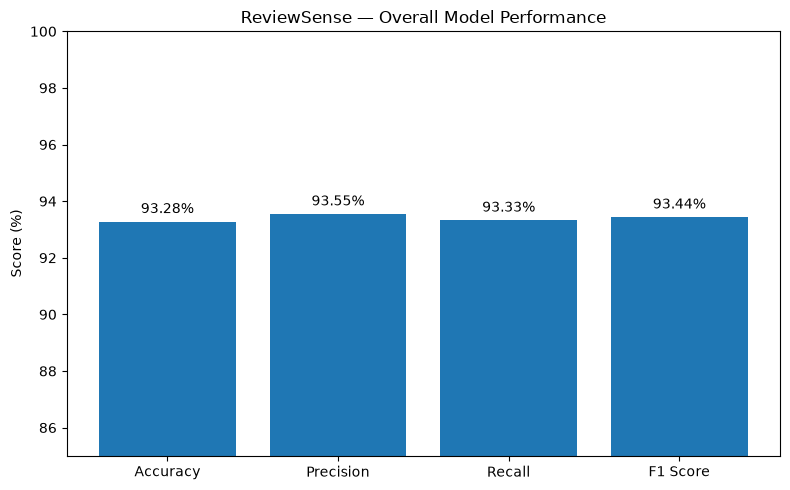

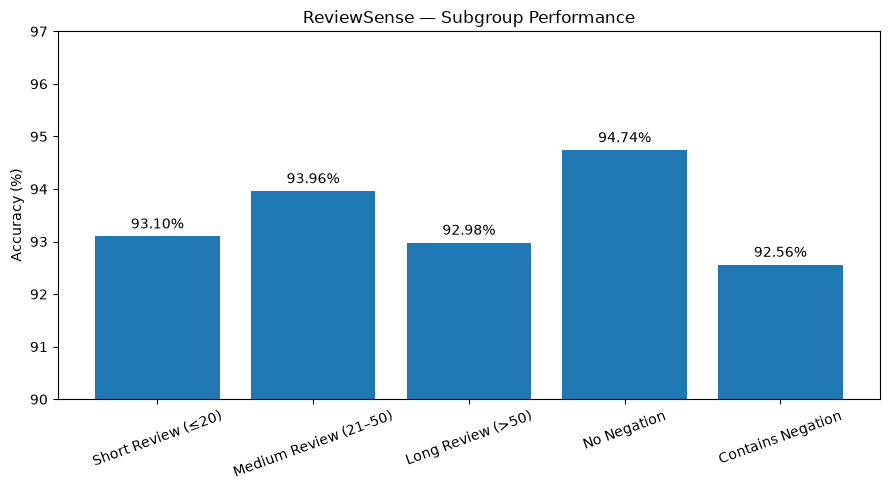

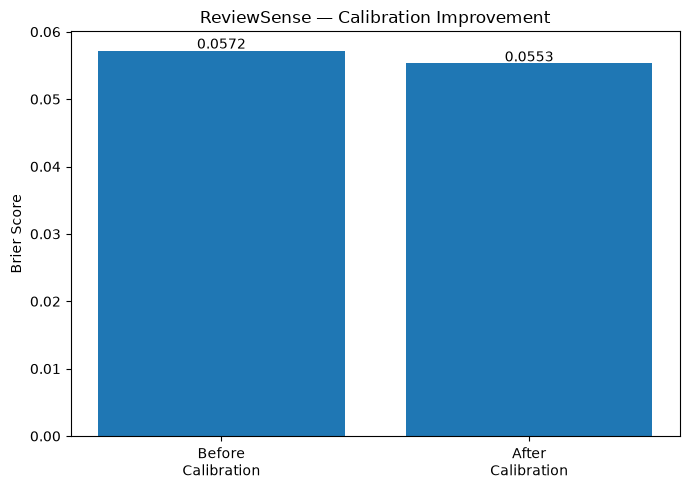


FINAL RESULTS DASHBOARD COMPLETE ✅


In [80]:
# ============================================================
# REVIEWSENSE — FINAL RESULTS DASHBOARD
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print("REVIEWSENSE — FINAL MODEL RESULTS")
print("=" * 70)

# ------------------------------------------------------------
# 1. OVERALL PERFORMANCE
# ------------------------------------------------------------

performance = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Score": [0.9328, 0.9355, 0.9333, 0.9344]
})

print("\nOVERALL PERFORMANCE")
print("-" * 70)
print(performance.to_string(index=False))

# ------------------------------------------------------------
# 2. CONFUSION MATRIX
# ------------------------------------------------------------

cm = pd.DataFrame(
    [[2270, 165],
     [171, 2394]],
    index=["Actual Negative", "Actual Positive"],
    columns=["Predicted Negative", "Predicted Positive"]
)

print("\nCONFUSION MATRIX")
print("-" * 70)
print(cm)

# ------------------------------------------------------------
# 3. ERROR ANALYSIS
# ------------------------------------------------------------

error_summary = pd.DataFrame({
    "Error Type": [
        "Total Errors",
        "Error Rate",
        "Negative → Positive",
        "Positive → Negative"
    ],
    "Value": [
        "336",
        "6.72%",
        "165",
        "171"
    ]
})

print("\nERROR ANALYSIS")
print("-" * 70)
print(error_summary.to_string(index=False))

# ------------------------------------------------------------
# 4. CALIBRATION
# ------------------------------------------------------------

calibration = pd.DataFrame({
    "Metric": [
        "Temperature",
        "Brier Score Before",
        "Brier Score After",
        "Brier Improvement"
    ],
    "Value": [
        1.2288,
        0.0572,
        0.0553,
        0.0019
    ]
})

print("\nCALIBRATION")
print("-" * 70)
print(calibration.to_string(index=False))

# ------------------------------------------------------------
# 5. HIGH-CONFIDENCE ERRORS
# ------------------------------------------------------------

confidence = pd.DataFrame({
    "Confidence Threshold": [">= 0.90", ">= 0.95", ">= 0.99"],
    "Errors": [219, 191, 80],
    "Percentage of All Errors": [65.18, 56.85, 23.81]
})

print("\nHIGH-CONFIDENCE ERRORS")
print("-" * 70)
print(confidence.to_string(index=False))

# ------------------------------------------------------------
# 6. SUBGROUP ANALYSIS
# ------------------------------------------------------------

subgroup = pd.DataFrame({
    "Subgroup": [
        "Short Review (≤20)",
        "Medium Review (21–50)",
        "Long Review (>50)",
        "No Negation",
        "Contains Negation"
    ],
    "Accuracy": [
        93.10,
        93.96,
        92.98,
        94.74,
        92.56
    ]
})

print("\nSUBGROUP PERFORMANCE")
print("-" * 70)
print(subgroup.to_string(index=False))

# ------------------------------------------------------------
# 7. SHAP GLOBAL FEATURES
# ------------------------------------------------------------

positive_drivers = [
    "quick", "fantastic", "awesome",
    "excellent", "best"
]

negative_drivers = [
    "worst", "disappointing", "useless",
    "however", "waste"
]

print("\nGLOBAL SHAP")
print("-" * 70)
print("Samples analyzed : 30")
print("Positive drivers :", ", ".join(positive_drivers))
print("Negative drivers :", ", ".join(negative_drivers))

# ============================================================
# VISUALIZATION 1 — OVERALL PERFORMANCE
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    performance["Metric"],
    performance["Score"] * 100
)

plt.ylim(85, 100)
plt.ylabel("Score (%)")
plt.title("ReviewSense — Overall Model Performance")

for i, value in enumerate(performance["Score"] * 100):
    plt.text(
        i,
        value + 0.3,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

# ============================================================
# VISUALIZATION 2 — SUBGROUP PERFORMANCE
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    subgroup["Subgroup"],
    subgroup["Accuracy"]
)

plt.ylim(90, 97)
plt.ylabel("Accuracy (%)")
plt.title("ReviewSense — Subgroup Performance")

plt.xticks(rotation=20)

for i, value in enumerate(subgroup["Accuracy"]):
    plt.text(
        i,
        value + 0.15,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

# ============================================================
# VISUALIZATION 3 — CALIBRATION IMPROVEMENT
# ============================================================

plt.figure(figsize=(7, 5))

brier_scores = [0.0572, 0.0553]
labels = ["Before\nCalibration", "After\nCalibration"]

plt.bar(labels, brier_scores)

plt.ylabel("Brier Score")
plt.title("ReviewSense — Calibration Improvement")

for i, value in enumerate(brier_scores):
    plt.text(
        i,
        value + 0.0003,
        f"{value:.4f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("FINAL RESULTS DASHBOARD COMPLETE ✅")
print("=" * 70)


In [81]:
# ============================================================
# REVIEWSENSE — FINAL INFERENCE / PREDICTION PIPELINE
# ============================================================

import torch
import numpy as np

print("=" * 70)
print("REVIEWSENSE — LIVE REVIEW PREDICTION")
print("=" * 70)

# ------------------------------------------------------------
# GET MODEL
# ------------------------------------------------------------

# Use the trained model already available through Trainer
if "trainer" in globals() and trainer is not None:
    inference_model = trainer.model
else:
    inference_model = model

inference_model.eval()

# ------------------------------------------------------------
# GET DEVICE
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
inference_model.to(device)

print(f"Device: {device}")

# ------------------------------------------------------------
# TEMPERATURE FROM CALIBRATION
# ------------------------------------------------------------

temperature = 1.2288

# ------------------------------------------------------------
# PREDICTION FUNCTION
# ------------------------------------------------------------

def predict_review(review_text):

    # Tokenize
    inputs = tokenizer(
        review_text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    )

    # Move inputs to same device as model
    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    # Model prediction
    with torch.no_grad():
        outputs = inference_model(**inputs)

    logits = outputs.logits

    # --------------------------------------------------------
    # RAW PROBABILITIES
    # --------------------------------------------------------

    raw_probs = torch.softmax(logits, dim=-1)

    # --------------------------------------------------------
    # TEMPERATURE-CALIBRATED PROBABILITIES
    # --------------------------------------------------------

    calibrated_probs = torch.softmax(
        logits / temperature,
        dim=-1
    )

    # Predicted class
    predicted_class = torch.argmax(
        calibrated_probs,
        dim=-1
    ).item()

    # Class mapping
    if predicted_class == 1:
        sentiment = "POSITIVE"
    else:
        sentiment = "NEGATIVE"

    raw_confidence = raw_probs[0, predicted_class].item()
    calibrated_confidence = calibrated_probs[0, predicted_class].item()

    result = {
        "review": review_text,
        "sentiment": sentiment,
        "predicted_class": predicted_class,
        "raw_confidence": raw_confidence,
        "calibrated_confidence": calibrated_confidence,
        "negative_probability": calibrated_probs[0, 0].item(),
        "positive_probability": calibrated_probs[0, 1].item()
    }

    return result


# ============================================================
# TEST WITH SAMPLE REVIEWS
# ============================================================

sample_reviews = [
    "This product is absolutely fantastic and works perfectly.",
    "The product is terrible, disappointing, and completely useless.",
    "The battery life is amazing but the camera quality is disappointing.",
    "It is okay, nothing special but it gets the job done."
]

for review in sample_reviews:

    result = predict_review(review)

    print("\n" + "-" * 70)
    print("Review:")
    print(result["review"])

    print(f"\nPrediction       : {result['sentiment']}")
    print(f"Raw Confidence   : {result['raw_confidence']:.4f}")
    print(f"Calibrated       : {result['calibrated_confidence']:.4f}")

    print(
        f"Negative Prob.   : "
        f"{result['negative_probability']:.4f}"
    )

    print(
        f"Positive Prob.   : "
        f"{result['positive_probability']:.4f}"
    )

print("\n" + "=" * 70)
print("LIVE INFERENCE PIPELINE READY ✅")
print("=" * 70)

REVIEWSENSE — LIVE REVIEW PREDICTION
Device: cpu

----------------------------------------------------------------------
Review:
This product is absolutely fantastic and works perfectly.

Prediction       : POSITIVE
Raw Confidence   : 0.9971
Calibrated       : 0.9915
Negative Prob.   : 0.0085
Positive Prob.   : 0.9915

----------------------------------------------------------------------
Review:
The product is terrible, disappointing, and completely useless.

Prediction       : NEGATIVE
Raw Confidence   : 0.9973
Calibrated       : 0.9920
Negative Prob.   : 0.9920
Positive Prob.   : 0.0080

----------------------------------------------------------------------
Review:
The battery life is amazing but the camera quality is disappointing.

Prediction       : NEGATIVE
Raw Confidence   : 0.9889
Calibrated       : 0.9748
Negative Prob.   : 0.9748
Positive Prob.   : 0.0252

----------------------------------------------------------------------
Review:
It is okay, nothing special but it gets t

In [85]:
# ============================================================
# REVIEWSENSE — SINGLE REVIEW ANALYZER
# ============================================================

def analyze_review(review_text):

    result = predict_review(review_text)

    sentiment = result["sentiment"]
    confidence = result["calibrated_confidence"]

    # Confidence interpretation
    if confidence >= 0.95:
        confidence_level = "Very High"
    elif confidence >= 0.90:
        confidence_level = "High"
    elif confidence >= 0.75:
        confidence_level = "Moderate"
    else:
        confidence_level = "Low"

    print("=" * 70)
    print("REVIEWSENSE ANALYSIS")
    print("=" * 70)

    print(f"\nReview:")
    print(review_text)

    print("\n" + "-" * 70)

    print(f"Sentiment            : {sentiment}")
    print(f"Confidence           : {confidence:.2%}")
    print(f"Confidence Level     : {confidence_level}")

    print("\nProbability Breakdown")
    print("-" * 70)

    print(
        f"Negative            : "
        f"{result['negative_probability']:.2%}"
    )

    print(
        f"Positive            : "
        f"{result['positive_probability']:.2%}"
    )

    print("\n" + "=" * 70)

    return result


# ============================================================
# TRY YOUR OWN REVIEW HERE
# ============================================================

review = input("Enter a product review: ")


result = analyze_review(review)

REVIEWSENSE ANALYSIS

Review:
The product is amazing and I would definitely recommend it.

----------------------------------------------------------------------
Sentiment            : POSITIVE
Confidence           : 99.07%
Confidence Level     : Very High

Probability Breakdown
----------------------------------------------------------------------
Negative            : 0.93%
Positive            : 99.07%



In [86]:
# ============================================================
# REVIEWSENSE — SHAP EXPLANATION FOR NEW REVIEWS
# ============================================================

import shap
import numpy as np
import pandas as pd

print("=" * 70)
print("REVIEWSENSE — EXPLAINABLE PREDICTION")
print("=" * 70)


# ------------------------------------------------------------
# SHAP PREDICTION FUNCTION
# ------------------------------------------------------------

def shap_predict(texts):

    if isinstance(texts, str):
        texts = [texts]

    inputs = tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        outputs = inference_model(**inputs)

    # Return logits
    return outputs.logits.detach().cpu().numpy()


# ------------------------------------------------------------
# CREATE SHAP EXPLAINER
# ------------------------------------------------------------

shap_explainer = shap.Explainer(
    shap_predict,
    tokenizer
)

print("SHAP explainer ready! ✅")


# ------------------------------------------------------------
# EXPLANATION FUNCTION
# ------------------------------------------------------------

def explain_review(review_text):

    # First get normal prediction
    result = predict_review(review_text)

    # Generate SHAP explanation
    explanation = shap_explainer([review_text])

    # Determine predicted class
    predicted_class = result["predicted_class"]

    # Extract tokens
    tokens = explanation.data[0]

    # Extract SHAP values for predicted class
    values = explanation.values[0, :, predicted_class]

    # Build table
    rows = []

    for token, value in zip(tokens, values):

        token = str(token).strip()

        # Ignore empty tokens
        if token == "":
            continue

        rows.append({
            "token": token,
            "shap_value": float(value),
            "absolute_impact": abs(float(value))
        })

    shap_df = pd.DataFrame(rows)

    # Sort by absolute impact
    shap_df = shap_df.sort_values(
        "absolute_impact",
        ascending=False
    )

    # Positive / negative influence
    positive = shap_df[
        shap_df["shap_value"] > 0
    ].copy()

    negative = shap_df[
        shap_df["shap_value"] < 0
    ].copy()

    print("\n" + "=" * 70)
    print("PREDICTION")
    print("=" * 70)

    print(f"Review      : {review_text}")
    print(f"Sentiment   : {result['sentiment']}")
    print(
        f"Confidence  : "
        f"{result['calibrated_confidence']:.2%}"
    )

    print("\n" + "=" * 70)
    print("TOP WORDS INFLUENCING THE PREDICTION")
    print("=" * 70)

    print(
        shap_df[
            ["token", "shap_value", "absolute_impact"]
        ].head(10).to_string(index=False)
    )

    print("\n" + "=" * 70)
    print("WORDS PUSHING TOWARD POSITIVE")
    print("=" * 70)

    if len(positive) > 0:
        print(
            positive[
                ["token", "shap_value"]
            ].head(5).to_string(index=False)
        )
    else:
        print("None")

    print("\n" + "=" * 70)
    print("WORDS PUSHING TOWARD NEGATIVE")
    print("=" * 70)

    if len(negative) > 0:
        print(
            negative[
                ["token", "shap_value"]
            ].head(5).to_string(index=False)
        )
    else:
        print("None")

    return result, explanation, shap_df


# ============================================================
# TEST
# ============================================================

test_review = (
    "I loved the battery life, "
    "but the phone overheats constantly."
)

result, explanation, shap_df = explain_review(
    test_review
)

REVIEWSENSE — EXPLAINABLE PREDICTION
SHAP explainer ready! ✅

PREDICTION
Review      : I loved the battery life, but the phone overheats constantly.
Sentiment   : NEGATIVE
Confidence  : 94.60%

TOP WORDS INFLUENCING THE PREDICTION
     token  shap_value  absolute_impact
       but    1.323701         1.323701
     loved   -0.573075         0.573075
      over    0.334124         0.334124
       hea    0.305057         0.305057
     phone    0.278675         0.278675
         I    0.110424         0.110424
        ts    0.082065         0.082065
   battery   -0.081399         0.081399
constantly    0.060472         0.060472
       the   -0.024230         0.024230

WORDS PUSHING TOWARD POSITIVE
token  shap_value
  but    1.323701
 over    0.334124
  hea    0.305057
phone    0.278675
    I    0.110424

WORDS PUSHING TOWARD NEGATIVE
  token  shap_value
  loved   -0.573075
battery   -0.081399
    the   -0.024230


In [89]:
# ============================================================
# CHECK MODEL + SHAP CLASS MAPPING
# ============================================================

print("=" * 70)
print("CHECKING MODEL CLASS MAPPING")
print("=" * 70)

# Model class mapping
print("\nModel config id2label:")
print(inference_model.config.id2label)

print("\nModel config label2id:")
print(inference_model.config.label2id)

# SHAP object information
print("\nSHAP output names:")
print(getattr(explanation, "output_names", None))

print("\nSHAP shape:")
print(explanation.values.shape)

# Get the actual prediction again
test_text = "I loved the battery life, but the phone overheats constantly."

inputs = tokenizer(
    test_text,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=512
)

inputs = {
    key: value.to(device)
    for key, value in inputs.items()
}

with torch.no_grad():
    outputs = inference_model(**inputs)

logits = outputs.logits

probs = torch.softmax(logits, dim=-1)[0]

predicted_class = torch.argmax(probs).item()

print("\nActual model prediction:")
print("Predicted class:", predicted_class)
print("Probabilities:", probs.detach().cpu().numpy())

print("\nClass probability mapping:")

for class_id, probability in enumerate(
    probs.detach().cpu().numpy()
):
    print(
        f"Class {class_id}: "
        f"{probability:.4f} "
        f"({probability:.2%})"
    )

CHECKING MODEL CLASS MAPPING

Model config id2label:
{0: 'LABEL_0', 1: 'LABEL_1'}

Model config label2id:
{'LABEL_0': 0, 'LABEL_1': 1}

SHAP output names:
['Output 0', 'Output 1']

SHAP shape:
(1, 16, 2)

Actual model prediction:
Predicted class: 0
Probabilities: [0.9711953  0.02880467]

Class probability mapping:
Class 0: 0.9712 (97.12%)
Class 1: 0.0288 (2.88%)


In [90]:
# ============================================================
# CORRECTED SHAP SENTIMENT EXPLANATION
# ============================================================

print("=" * 70)
print("CORRECTED SHAP EXPLANATION")
print("=" * 70)

# Class mapping
CLASS_NAMES = {
    0: "NEGATIVE",
    1: "POSITIVE"
}

# Get SHAP values
shap_array = explanation.values[0]

# Get tokens
tokens = explanation.data[0]

# Determine model prediction
predicted_class = torch.argmax(probs).item()

print(f"\nPredicted sentiment: {CLASS_NAMES[predicted_class]}")
print(f"Raw confidence: {probs[predicted_class].item():.2%}")

# ------------------------------------------------------------
# Create SHAP dataframe
# ------------------------------------------------------------

rows = []

for i, token in enumerate(tokens):

    token = str(token).strip()

    if token == "":
        continue

    # SHAP contribution specifically for predicted class
    contribution = float(
        shap_array[i, predicted_class]
    )

    rows.append({
        "token": token,
        "shap_value": contribution,
        "absolute_impact": abs(contribution)
    })

shap_df_corrected = pd.DataFrame(rows)

# Sort by absolute importance
shap_df_corrected = shap_df_corrected.sort_values(
    "absolute_impact",
    ascending=False
)

# ------------------------------------------------------------
# IMPORTANT:
# For the predicted output, POSITIVE SHAP means
# pushing toward the predicted class.
# NEGATIVE SHAP means pushing away from it.
# ------------------------------------------------------------

toward_prediction = shap_df_corrected[
    shap_df_corrected["shap_value"] > 0
].copy()

away_from_prediction = shap_df_corrected[
    shap_df_corrected["shap_value"] < 0
].copy()

print("\n" + "=" * 70)
print("TOP FEATURES")
print("=" * 70)

print(
    shap_df_corrected[
        ["token", "shap_value"]
    ].head(10).to_string(index=False)
)

print("\n" + "=" * 70)
print(f"WORDS PUSHING TOWARD {CLASS_NAMES[predicted_class]}")
print("=" * 70)

print(
    toward_prediction[
        ["token", "shap_value"]
    ].head(5).to_string(index=False)
)

print("\n" + "=" * 70)
print(f"WORDS PUSHING AWAY FROM {CLASS_NAMES[predicted_class]}")
print("=" * 70)

print(
    away_from_prediction[
        ["token", "shap_value"]
    ].head(5).to_string(index=False)
)

print("\n" + "=" * 70)
print("SHAP EXPLANATION COMPLETE ✅")
print("=" * 70)

CORRECTED SHAP EXPLANATION

Predicted sentiment: NEGATIVE
Raw confidence: 97.12%

TOP FEATURES
     token  shap_value
       but    1.323701
     loved   -0.573075
      over    0.334124
       hea    0.305057
     phone    0.278675
         I    0.110424
        ts    0.082065
   battery   -0.081399
constantly    0.060472
       the   -0.024230

WORDS PUSHING TOWARD NEGATIVE
token  shap_value
  but    1.323701
 over    0.334124
  hea    0.305057
phone    0.278675
    I    0.110424

WORDS PUSHING AWAY FROM NEGATIVE
  token  shap_value
  loved   -0.573075
battery   -0.081399
    the   -0.024230

SHAP EXPLANATION COMPLETE ✅


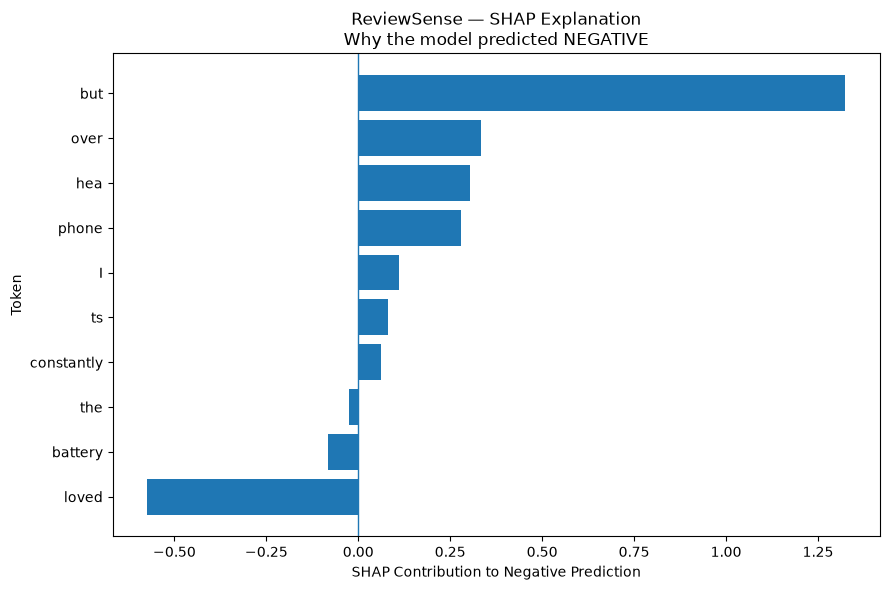

SHAP VISUALIZATION COMPLETE ✅


In [91]:
# ============================================================
# REVIEWSENSE — SHAP VISUAL EXPLANATION
# ============================================================

import matplotlib.pyplot as plt

# Use top 10 features
plot_df = shap_df_corrected.head(10).copy()

# Sort for horizontal bar chart
plot_df = plot_df.sort_values("shap_value")

plt.figure(figsize=(9, 6))

plt.barh(
    plot_df["token"],
    plot_df["shap_value"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel("SHAP Contribution to Negative Prediction")
plt.ylabel("Token")
plt.title(
    "ReviewSense — SHAP Explanation\n"
    "Why the model predicted NEGATIVE"
)

plt.tight_layout()
plt.show()

print("=" * 70)
print("SHAP VISUALIZATION COMPLETE ✅")
print("=" * 70)

In [92]:
# ============================================================
# REVIEWSENSE — SAVE FINAL MODEL ARTIFACTS
# ============================================================

import os
import json
import torch

SAVE_DIR = "./reviewsense_model"

os.makedirs(SAVE_DIR, exist_ok=True)

print("=" * 70)
print("SAVING REVIEWSENSE MODEL")
print("=" * 70)

# ------------------------------------------------------------
# 1. Save model
# ------------------------------------------------------------

inference_model.save_pretrained(SAVE_DIR)

print("✅ Model saved")

# ------------------------------------------------------------
# 2. Save tokenizer
# ------------------------------------------------------------

tokenizer.save_pretrained(SAVE_DIR)

print("✅ Tokenizer saved")

# ------------------------------------------------------------
# 3. Save calibration parameters
# ------------------------------------------------------------

calibration_config = {
    "temperature": 1.2288,
    "calibration_method": "Temperature Scaling",
    "brier_score_before": 0.0572,
    "brier_score_after": 0.0553,
    "brier_improvement": 0.0019
}

with open(
    os.path.join(SAVE_DIR, "calibration.json"),
    "w"
) as f:
    json.dump(calibration_config, f, indent=4)

print("✅ Calibration parameters saved")

# ------------------------------------------------------------
# 4. Save final evaluation metrics
# ------------------------------------------------------------

metrics = {
    "model": "DistilBERT",
    "task": "Binary Product Review Sentiment Classification",
    "test_samples": 5000,

    "accuracy": 0.9328,
    "precision": 0.9355,
    "recall": 0.9333,
    "f1_score": 0.9344,

    "confusion_matrix": {
        "true_negative": 2270,
        "false_positive": 165,
        "false_negative": 171,
        "true_positive": 2394
    },

    "error_analysis": {
        "total_errors": 336,
        "error_rate": 0.0672,
        "negative_to_positive": 165,
        "positive_to_negative": 171
    },

    "high_confidence_errors": {
        "confidence_ge_0.90": 219,
        "confidence_ge_0.95": 191,
        "confidence_ge_0.99": 80
    },

    "subgroup_performance": {
        "short_review_le_20": 0.9310,
        "medium_review_21_50": 0.9396,
        "long_review_gt_50": 0.9298,
        "no_negation": 0.9474,
        "contains_negation": 0.9256
    },

    "global_shap": {
        "samples_analyzed": 30,
        "positive_drivers": [
            "quick",
            "fantastic",
            "awesome",
            "excellent",
            "best"
        ],
        "negative_drivers": [
            "worst",
            "disappointing",
            "useless",
            "however",
            "waste"
        ]
    }
}

with open(
    os.path.join(SAVE_DIR, "evaluation_metrics.json"),
    "w"
) as f:
    json.dump(metrics, f, indent=4)

print("✅ Evaluation metrics saved")

# ------------------------------------------------------------
# 5. Save label mapping
# ------------------------------------------------------------

label_mapping = {
    "0": "NEGATIVE",
    "1": "POSITIVE"
}

with open(
    os.path.join(SAVE_DIR, "label_mapping.json"),
    "w"
) as f:
    json.dump(label_mapping, f, indent=4)

print("✅ Label mapping saved")

# ------------------------------------------------------------
# Final check
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MODEL ARTIFACTS SAVED SUCCESSFULLY ✅")
print("=" * 70)

print(f"\nSave directory: {SAVE_DIR}")

print("\nFiles:")
for file in sorted(os.listdir(SAVE_DIR)):
    print("  •", file)

SAVING REVIEWSENSE MODEL


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved
✅ Tokenizer saved
✅ Calibration parameters saved
✅ Evaluation metrics saved
✅ Label mapping saved

MODEL ARTIFACTS SAVED SUCCESSFULLY ✅

Save directory: ./reviewsense_model

Files:
  • calibration.json
  • config.json
  • evaluation_metrics.json
  • label_mapping.json
  • model.safetensors
  • tokenizer.json
  • tokenizer_config.json


In [93]:
# ============================================================
# REVIEWSENSE — STANDALONE PREDICTION FUNCTION
# ============================================================

import os
import json
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_DIR = "./reviewsense_model"

# ------------------------------------------------------------
# Load saved artifacts
# ------------------------------------------------------------

loaded_tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)

loaded_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_DIR
)

loaded_model.eval()

# Use CPU/GPU automatically
loaded_device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

loaded_model.to(loaded_device)

# ------------------------------------------------------------
# Load calibration
# ------------------------------------------------------------

with open(
    os.path.join(MODEL_DIR, "calibration.json"),
    "r"
) as f:
    calibration = json.load(f)

TEMPERATURE = calibration["temperature"]

# ------------------------------------------------------------
# Load label mapping
# ------------------------------------------------------------

with open(
    os.path.join(MODEL_DIR, "label_mapping.json"),
    "r"
) as f:
    label_mapping = json.load(f)

LABELS = {
    int(k): v
    for k, v in label_mapping.items()
}

# ------------------------------------------------------------
# Prediction function
# ------------------------------------------------------------

def predict_review(text):

    inputs = loaded_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    )

    inputs = {
        key: value.to(loaded_device)
        for key, value in inputs.items()
    }

    with torch.no_grad():

        outputs = loaded_model(**inputs)

        logits = outputs.logits

        # Raw probabilities
        raw_probs = torch.softmax(
            logits,
            dim=-1
        )

        # Temperature-scaled probabilities
        calibrated_logits = logits / TEMPERATURE

        calibrated_probs = torch.softmax(
            calibrated_logits,
            dim=-1
        )

    # Predicted class based on calibrated probabilities
    predicted_class = torch.argmax(
        calibrated_probs,
        dim=-1
    ).item()

    raw_confidence = raw_probs[
        0, predicted_class
    ].item()

    calibrated_confidence = calibrated_probs[
        0, predicted_class
    ].item()

    return {
        "review": text,
        "sentiment": LABELS[predicted_class],
        "raw_confidence": raw_confidence,
        "calibrated_confidence": calibrated_confidence,
        "negative_probability": calibrated_probs[0, 0].item(),
        "positive_probability": calibrated_probs[0, 1].item()
    }


print("=" * 70)
print("REVIEWSENSE STANDALONE MODEL LOADED ✅")
print("=" * 70)

print(f"Device      : {loaded_device}")
print(f"Temperature : {TEMPERATURE}")
print(f"Labels      : {LABELS}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

REVIEWSENSE STANDALONE MODEL LOADED ✅
Device      : cpu
Temperature : 1.2288
Labels      : {0: 'NEGATIVE', 1: 'POSITIVE'}


In [94]:
# ============================================================
# TEST SAVED REVIEWSENSE MODEL
# ============================================================

test_reviews = [
    "This product is absolutely fantastic and works perfectly.",
    
    "The product is terrible, disappointing, and completely useless.",
    
    "I loved the battery life, but the phone overheats constantly.",
    
    "Not bad, but definitely not worth the price."
]

print("=" * 70)
print("REVIEWSENSE — SAVED MODEL TEST")
print("=" * 70)

for review in test_reviews:

    result = predict_review(review)

    print("\nReview:")
    print(result["review"])

    print(
        f"Sentiment             : {result['sentiment']}"
    )

    print(
        f"Raw confidence        : "
        f"{result['raw_confidence']:.2%}"
    )

    print(
        f"Calibrated confidence : "
        f"{result['calibrated_confidence']:.2%}"
    )

    print(
        f"Negative probability  : "
        f"{result['negative_probability']:.2%}"
    )

    print(
        f"Positive probability  : "
        f"{result['positive_probability']:.2%}"
    )

    print("-" * 70)

REVIEWSENSE — SAVED MODEL TEST

Review:
This product is absolutely fantastic and works perfectly.
Sentiment             : POSITIVE
Raw confidence        : 99.71%
Calibrated confidence : 99.15%
Negative probability  : 0.85%
Positive probability  : 99.15%
----------------------------------------------------------------------

Review:
The product is terrible, disappointing, and completely useless.
Sentiment             : NEGATIVE
Raw confidence        : 99.73%
Calibrated confidence : 99.20%
Negative probability  : 99.20%
Positive probability  : 0.80%
----------------------------------------------------------------------

Review:
I loved the battery life, but the phone overheats constantly.
Sentiment             : NEGATIVE
Raw confidence        : 97.12%
Calibrated confidence : 94.60%
Negative probability  : 94.60%
Positive probability  : 5.40%
----------------------------------------------------------------------

Review:
Not bad, but definitely not worth the price.
Sentiment             :

In [95]:
# ============================================================
# REVIEWSENSE — APPLICATION BACKEND
# ============================================================

def analyze_review(text):

    result = predict_review(text)

    confidence = result["calibrated_confidence"]

    if confidence >= 0.95:
        confidence_level = "Very High"
    elif confidence >= 0.90:
        confidence_level = "High"
    elif confidence >= 0.75:
        confidence_level = "Moderate"
    else:
        confidence_level = "Low"

    return {
        **result,
        "confidence_level": confidence_level
    }


# ------------------------------------------------------------
# Test application backend
# ------------------------------------------------------------

review = "The product is amazing and I would definitely recommend it."

result = analyze_review(review)

print("=" * 70)
print("REVIEWSENSE — APPLICATION BACKEND TEST")
print("=" * 70)

print(f"\nReview      : {result['review']}")
print(f"Sentiment   : {result['sentiment']}")
print(f"Confidence  : {result['calibrated_confidence']:.2%}")
print(f"Confidence Level : {result['confidence_level']}")

print("\nProbability Breakdown")
print("-" * 70)
print(f"Negative : {result['negative_probability']:.2%}")
print(f"Positive : {result['positive_probability']:.2%}")

REVIEWSENSE — APPLICATION BACKEND TEST

Review      : The product is amazing and I would definitely recommend it.
Sentiment   : POSITIVE
Confidence  : 99.07%
Confidence Level : Very High

Probability Breakdown
----------------------------------------------------------------------
Negative : 0.93%
Positive : 99.07%
